<h1>Pontificia Universidade Católica de Minas Gerais</h1>
<h2>PÓS-GRADUAÇÃO EM Inteligencia artificial e aprendizado de máquina</h2>


* Nome do aluno: Wagner Jose Vaconcelos
* Matrícula: 1665641
* E-mail: 1665641@sga.pucminas.br
* Professor(a): Maurício Rodrigues da Silva
* Disciplina: "Machine Learning"
* Atividade: Trabalho Final

## Objetivos

Desenvolver um projeto completo de Machine Learning, desde a exploração inicial dos dados até a disponibilização do modelo em uma interface gráfica interativa. Esta atividade visa demonstrar o seu domínio sobre todas as etapas do ciclo de vida de um projeto de ciência de dados!

## 1. Definição do problema

**Base de dados**: A base de dados selecionada foi a "Healthy Diet & Calorie Intake: Nutrition & Health" que contem detalhes de dieta e de saude de 6000 pessoas com 15 features.

**Objetivo**: O problema a ser resolvido será definir atraves do treinamento dos dados desses pacientes e usando modelos de machine learning definir se atraves de alguns dados definir se o paciente tem uma dieta e rotina consideradas saudaveis, não sendo acima do peso ou obeso.

**Tipo de problema**: Classificação binária 0 - Não Saudavel 1 - Saudavel.

**Dataset**: Healthy Diet & Calorie Intake: Nutrition & Health


#### 2. Importação das bibliotecas e do Dataset

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import plotly.express as px
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


file_path = 'dataset/healthy_diet_calorie_intake.csv'

# Carregando o dataset a partir do arquivo local.
health_data = pd.read_csv(file_path, sep=',')

#### 3 - Analise exploratoria do dataset

In [3]:
health_data.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,P0004,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,P0005,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy


In [4]:
health_data.tail()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
5995,P5996,45,Female,161.1,79.1,30.5,Lightly Active,2039,2296,85.0,305.9,81.4,2.4,Balanced,Obese
5996,P5997,53,Female,157.7,63.7,25.6,Sedentary,1555,1851,177.0,179.7,47.1,1.8,High Protein,Overweight
5997,P5998,43,Female,154.0,81.8,34.5,Athlete,2840,3601,139.7,483.3,123.2,4.4,Mediterranean,Obese
5998,P5999,51,Female,162.8,77.8,29.4,Lightly Active,1994,2126,118.7,51.9,160.4,2.8,Keto,Overweight
5999,P6000,25,Male,171.5,75.9,25.8,Athlete,3394,4001,163.3,623.0,95.1,4.4,Vegan,Overweight


In [5]:
health_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  6000 non-null   str    
 1   Age                        6000 non-null   int64  
 2   Gender                     6000 non-null   str    
 3   Height_cm                  6000 non-null   float64
 4   Weight_kg                  6000 non-null   float64
 5   BMI                        6000 non-null   float64
 6   Activity_Level             6000 non-null   str    
 7   Daily_Calorie_Requirement  6000 non-null   int64  
 8   Daily_Calorie_Consumed     6000 non-null   int64  
 9   Protein_Intake_g           6000 non-null   float64
 10  Carbohydrate_Intake_g      6000 non-null   float64
 11  Fat_Intake_g               6000 non-null   float64
 12  Water_Intake_Liters        6000 non-null   float64
 13  Diet_Type                  6000 non-null   str    
 14  Hea

In [6]:
health_data.describe()

,Age,Height_cm,Weight_kg,BMI,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,48.817167,168.592533,74.070933,26.094300,2286.223833,2490.520333,123.773150,288.035317,93.698417,2.734917
std,18.141837,9.160213,12.417877,4.162643,469.541134,602.279679,61.999158,123.914738,43.953993,0.681486
min,18.000000,145.000000,40.000000,12.900000,1223.000000,1000.000000,17.400000,-23.600000,23.200000,1.500000
25%,33.000000,161.700000,65.500000,23.300000,1941.000000,2057.000000,78.800000,229.100000,65.900000,2.200000
50%,48.000000,168.200000,74.100000,26.000000,2232.500000,2433.000000,108.900000,297.150000,82.300000,2.600000
75%,65.000000,175.200000,82.700000,28.900000,2581.250000,2859.000000,155.100000,366.125000,105.100000,3.100000
max,80.000000,198.600000,116.600000,44.000000,4079.000000,5158.000000,457.500000,729.700000,341.700000,5.000000


### 4 - Analise das Variaveis

Encotramos as seguintes colunas:

**Colunas do dataset:**


Person_ID
Unique identifier for each individual (e.g. P0001). Not a predictive feature.

Age
Age of the individual in years across multiple life stages.

Gender
Gender of the individual — Male, Female, or Other.

Height_cm
Height measured in centimeters. Used to calculate BMI.

Weight_kg
Body weight in kilograms. Key metric for health assessment.

BMI
Body Mass Index = weight(kg) / height(m)². Indicates Healthy, Overweight, Obese or Underweight.

Activity_Level
Physical activity level — Sedentary, Lightly Active, Moderately Active, Very Active, Athlete.

Daily_Calorie_Requirement
Recommended daily calorie intake based on age, gender, weight, height and activity level (TDEE).

Daily_Calorie_Consumed
Actual daily calories consumed. Compare with Daily_Calorie_Requirement to find calorie surplus or deficit.

Protein_Intake_g
Daily protein intake in grams. Varies across diet types, especially High Protein and Vegan diets.

Carbohydrate_Intake_g
Daily carbohydrate intake in grams. Notably low in Keto diet followers.

Fat_Intake_g
Daily fat intake in grams. Higher in Keto and Mediterranean diet types.

Water_Intake_Liters
Daily water consumption in liters. Important for metabolism and overall health.

Diet_Type
Dietary pattern followed — Keto, Vegan, Balanced, Mediterranean, High Protein, Vegetarian.

Health_Status
Target variable — Health classification of the individual. Categories: Healthy, Overweight, Obese, Underweight. Use as label for classification models.

Os tipos de dados parecem estar corretos.

### 4 - Analise das Variaveis

In [38]:
print("\nDistribuição da variável alvo (Health_Status):")
display(health_data["Health_Status"].value_counts())


Distribuição da variável alvo (Health_Status):


Health_Status
Overweight     2500
Healthy        2249
Obese          1076
Underweight     175
Name: count, dtype: int64

Temos quase a metade health, então podemos utilizar como treino.

In [39]:
health_data.isnull().sum()[health_data.isnull().sum() > 0]

Series([], dtype: int64)

Não possuimos valores nulos

In [40]:
duplicados = health_data.duplicated().sum()
print(f'Linhas duplicadas: {duplicados}')

if duplicados > 0:
    health_data = health_data.drop_duplicates()
    print('Duplicatas removidas.')

Linhas duplicadas: 0


Não há dados faltantes ou duplicados e a integridade dos dados está boa.


#### 5. Analise gráfica e de correlação entre as variaves

In [41]:
health_data['is_healthy'] = health_data['Health_Status'].map({'Healthy': 1, 'Overweight': 0, 'Obese': 0, 'Underweight': 0})

In [42]:
print("\nDistribuição da variável alvo (is_healthy):")
display(health_data["is_healthy"].value_counts())



Distribuição da variável alvo (is_healthy):


is_healthy
0    3751
1    2249
Name: count, dtype: int64

Criei uma coluna binaria de Health para fazer a correlação entre as variaveis

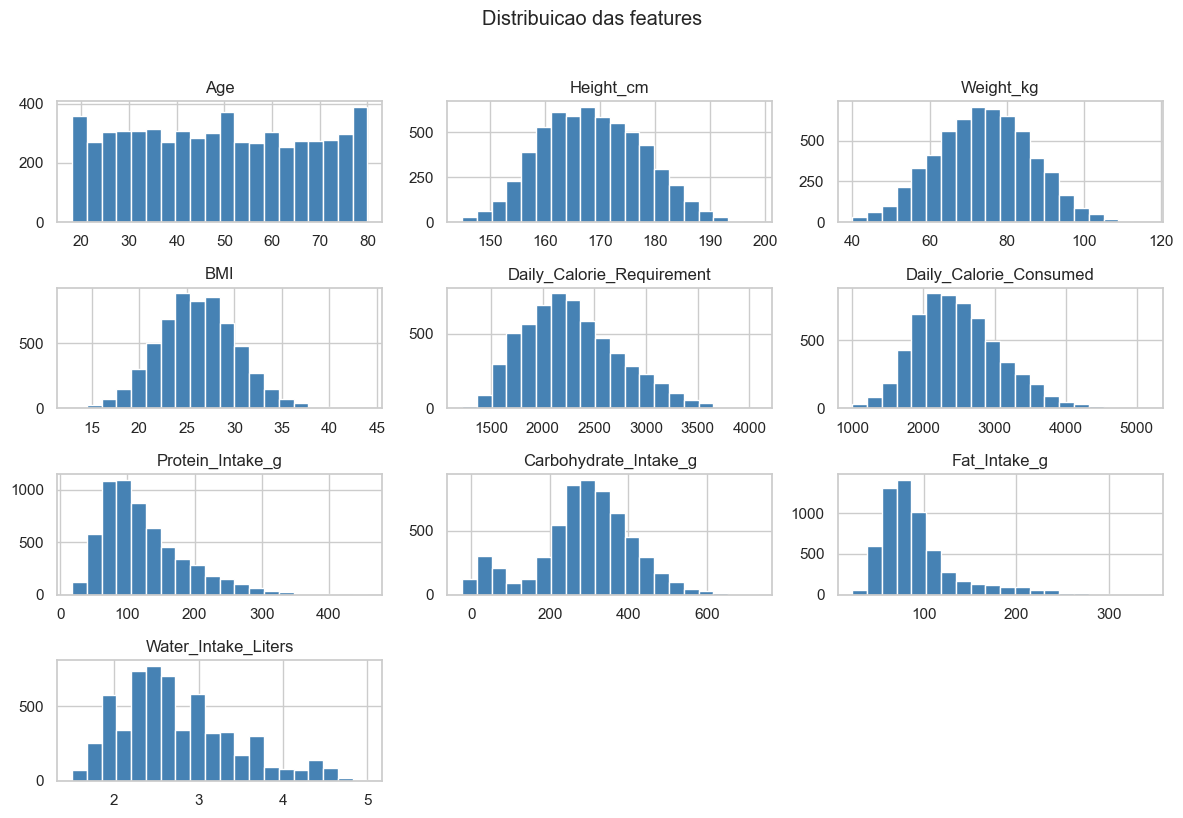

In [16]:
health_data.drop(columns='is_healthy').hist(bins=20, figsize=(12, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribuicao das features', y=1.02)
plt.tight_layout()
plt.show()

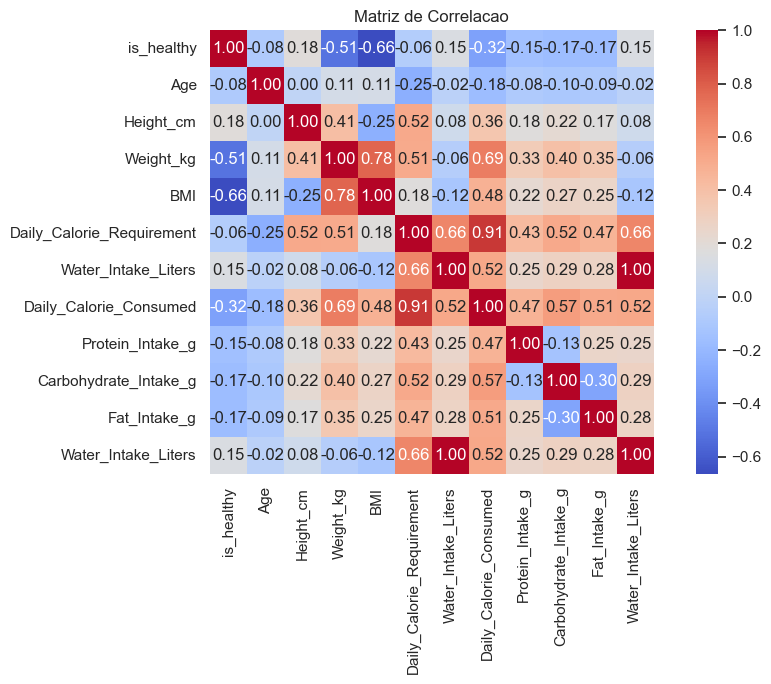

In [23]:
plt.figure(figsize=(10, 7))
sns.heatmap(health_data[['is_healthy','Age', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Calorie_Requirement', 'Water_Intake_Liters', 'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters']].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlacao')
plt.tight_layout()
plt.show()

Algumas apresentam baixa correlação e algumas estão melhores como a negativa de BMI e de Calorias diarias consumidas, porém a consumo de agua está com exatamente 1 o que não parece ser real, vou remover da analise.

**3.3 Identificação de padrões e outliers

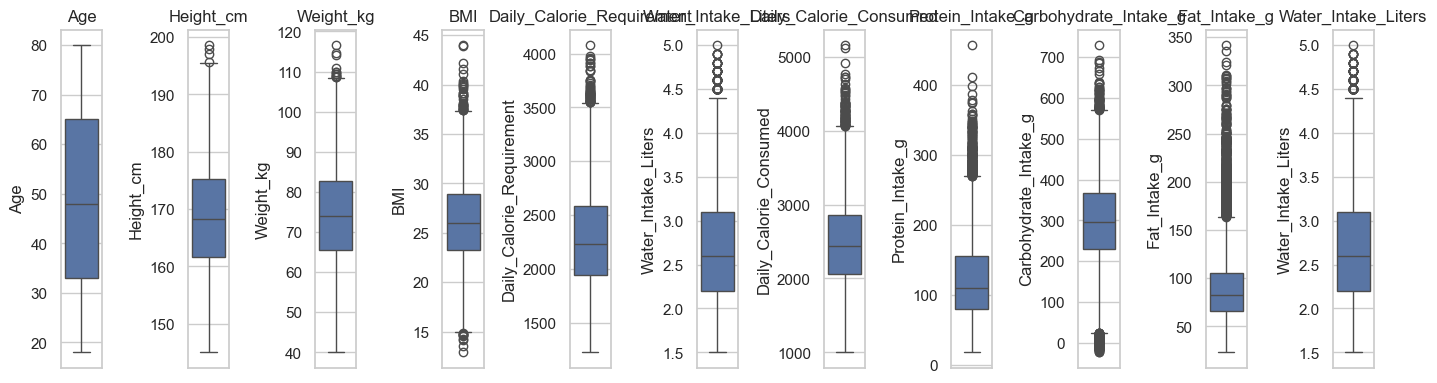

In [25]:
colunas_numericas = ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Calorie_Requirement', 'Water_Intake_Liters', 'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters']

fig, axes = plt.subplots(1, 11, figsize=(14, 4))

for ax, col in zip(axes, colunas_numericas):
    sns.boxplot(y=health_data[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()

Temos muitos outliers nas distribuiçoes, principalmente nas relacionadas a agua, carboidratos, gorduras e proteinas o que acho muito dificil de uma pessoa saber para ajudar no modelo, nesse caso pretendo retirar e deixar apenas calorias necessarias e calorias consumidas.

Também acho desnecessario incluir altura e peso,e BMI, acredito que uma ou outra sera suficiente, já que uma depende das outras duas, como BMI tem mais outliers, vou usar peso e altura.

In [27]:
variaveis_categoricas = ['Gender', 'Activity_Level', 'Diet_Type']

for var in variaveis_categoricas:
    grafico = px.pie(health_data, names=var, title=f'Distribuição de {var}')
    grafico.show()

In [33]:
# Selecionando as variáveis numéricas
X = health_data[['Age', 'Height_cm', 'Weight_kg', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed']]
X = sm.add_constant(X)  # Adiciona intercepto

# Calculando o VIF para todas as variáveis
vif_data = pd.DataFrame({
    "Variável": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif_data)

                    Variável         VIF
0                      const  424.190281
1                        Age    1.173905
2                  Height_cm    2.128850
3                  Weight_kg    3.315190
4  Daily_Calorie_Requirement   12.081260
5     Daily_Calorie_Consumed   14.435305


Existe a possibilidade de multicolinearidade entre a variavel de caloria necessarias e consumidas, acho que posso fazer é subtrair as duas em uma unica feature, uma vez que o que importa mesmo é a diferença.

In [43]:
health_data['Calorie_Balance'] = (
    health_data['Daily_Calorie_Requirement'] -
    health_data['Daily_Calorie_Consumed']
)

display(health_data[['Daily_Calorie_Requirement', 'Daily_Calorie_Consumed', 'Calorie_Balance']].head())

,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Calorie_Balance
0,2852,2625,227
1,1904,2044,-140
2,2009,2540,-531
3,2318,2096,222
4,2144,1937,207


In [44]:
# Selecionando as variáveis numéricas
X = health_data[['Age', 'Height_cm', 'Weight_kg', 'Calorie_Balance']]
X = sm.add_constant(X)  # Adiciona intercepto

# Calculando o VIF para todas as variáveis
vif_data = pd.DataFrame({
    "Variável": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif_data)

          Variável         VIF
0            const  392.929513
1              Age    1.017786
2        Height_cm    1.744066
3        Weight_kg    3.231721
4  Calorie_Balance    2.670792


Pronto, sem multicolinearidade agora.

### 7 - Pre-processamento e modelos

In [45]:
# Separar features desnecessárias e variável alvo
features_to_drop = [col for col in ['is_healthy', 'Person_ID', 'Health_Status', 'BMI', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters'] if col in health_data.columns]
X = health_data.drop(columns=features_to_drop)
y = health_data['is_healthy']

# Identificar colunas numéricas e categóricas
colunas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
colunas_categoricas = X.select_dtypes(exclude=[np.number]).columns.tolist()

print('Variáveis numéricas:', colunas_numericas)
print('Variáveis categóricas:', colunas_categoricas)

Variáveis numéricas: ['Age', 'Height_cm', 'Weight_kg', 'Calorie_Balance']
Variáveis categóricas: ['Gender', 'Activity_Level', 'Diet_Type']


Dividir em variaveis numericas e categoricas

In [46]:

# Dividir em treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

# Pipeline de pré-processamento
preprocessador = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), colunas_numericas),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), colunas_categoricas)
    ],
    remainder='drop'
)

# Aplicar transformação nas bases de treino e teste
X_train_prep = preprocessador.fit_transform(X_train)
X_test_prep = preprocessador.transform(X_test)

# Nome das colunas após one-hot encoding
nomes_colunas = preprocessador.get_feature_names_out()

X_train_prep_df = pd.DataFrame(X_train_prep, columns=nomes_colunas, index=X_train.index)
X_test_prep_df = pd.DataFrame(X_test_prep, columns=nomes_colunas, index=X_test.index)

print('\nShape após pré-processamento:')
print('Treino:', X_train_prep_df.shape)
print('Teste :', X_test_prep_df.shape)

X_train_prep_df.head()

Treino: 4200 amostras | Teste: 1800 amostras

Shape após pré-processamento:
Treino: (4200, 18)
Teste : (1800, 18)


,num__Age,num__Height_cm,num__Weight_kg,num__Calorie_Balance,cat__Gender_Female,cat__Gender_Male,cat__Gender_Other,cat__Activity_Level_Athlete,cat__Activity_Level_Lightly Active,cat__Activity_Level_Moderately Active,cat__Activity_Level_Sedentary,cat__Activity_Level_Very Active,cat__Diet_Type_Balanced,cat__Diet_Type_High Protein,cat__Diet_Type_Keto,cat__Diet_Type_Mediterranean,cat__Diet_Type_Vegan,cat__Diet_Type_Vegetarian
5215,1.462770,0.146209,-0.374131,1.269431,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4678,0.582357,-0.791145,-0.829638,1.015217,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3161,-0.848315,0.135181,1.350287,-2.574596,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1176,-0.958366,-0.934505,-0.650689,-0.571696,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1426,1.242667,1.447477,-0.658823,-0.132599,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


Apos as transformações obtemos 18 features para ser utilizadas nos modelos, usando one hot encoder.

### 7. Seleção e Treinamento do Modelo

In [47]:
# Dicionario para guardar os resultados de cada modelo
resultados = {}

def avaliar_modelo(nome, modelo, X_tr, X_te, y_tr, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    acc    = accuracy_score(y_te, y_pred)
    auc    = roc_auc_score(y_te, modelo.predict_proba(X_te)[:, 1])
    resultados[nome] = {'Acuracia': round(acc, 4), 'AUC-ROC': round(auc, 4)}
    print(f'\n--- {nome} ---')
    print(f'Acuracia: {acc:.4f} | AUC-ROC: {auc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Baixo Risco', 'Alto Risco']))
    # Matriz de confusao
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Real 0', 'Real 1'])
    plt.title(f'Matriz de Confusao - {nome}')
    plt.tight_layout()
    plt.show()
    return modelo

Vou treinar os 2 modelos sugeridos para a comparação desse dataset.

#### 7.1 Naivee bayes


--- Naive Bayes ---
Acuracia: 0.8722 | AUC-ROC: 0.9433
              precision    recall  f1-score   support

 Baixo Risco       0.90      0.90      0.90      1125
  Alto Risco       0.83      0.83      0.83       675

    accuracy                           0.87      1800
   macro avg       0.86      0.86      0.86      1800
weighted avg       0.87      0.87      0.87      1800



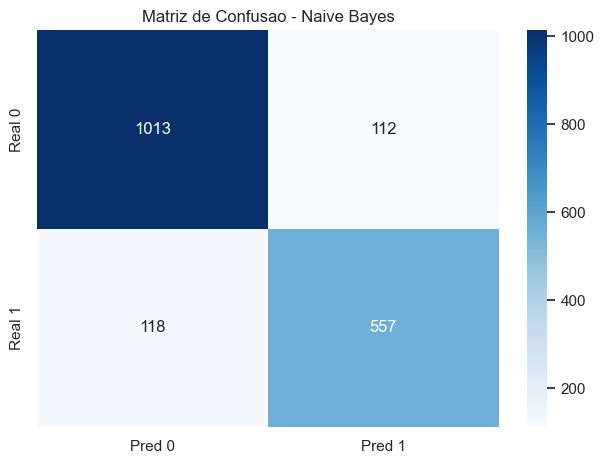

In [48]:
nb = avaliar_modelo('Naive Bayes', GaussianNB(),
                    X_train_prep_df, X_test_prep_df, y_train, y_test)

Performou razoavel para accuracia.

### 7.2 Redes Neurais


--- Rede Neural MLP ---
Acuracia: 0.9939 | AUC-ROC: 0.9998
              precision    recall  f1-score   support

 Baixo Risco       1.00      0.99      1.00      1125
  Alto Risco       0.99      0.99      0.99       675

    accuracy                           0.99      1800
   macro avg       0.99      0.99      0.99      1800
weighted avg       0.99      0.99      0.99      1800



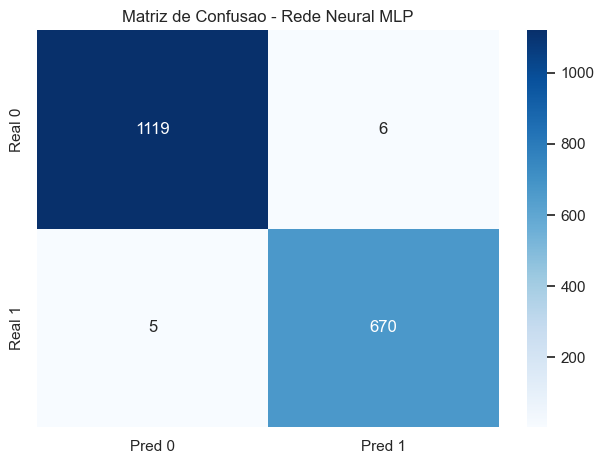

In [49]:
mlp = avaliar_modelo('Rede Neural MLP',
                     MLPClassifier(hidden_layer_sizes=(200,),
                                   activation='relu',
                                   max_iter=700,
                                   random_state=42),
                     X_train_prep_df, X_test_prep_df, y_train, y_test)

Performou quase até bem demais os parametros acima definidos.


### 6. Avaliação do Modelo

Melhor modelo: Rede Neural MLP
Acurácia: 0.9939
Precisão: 0.9911
Recall: 0.9926
F1-score: 0.9919
AUC-ROC: 0.9998

Relatório de classificação:
              precision    recall  f1-score   support

Não Saudável       1.00      0.99      1.00      1125
    Saudável       0.99      0.99      0.99       675

    accuracy                           0.99      1800
   macro avg       0.99      0.99      0.99      1800
weighted avg       0.99      0.99      0.99      1800


Matriz de confusão:
[[1119    6]
 [   5  670]]


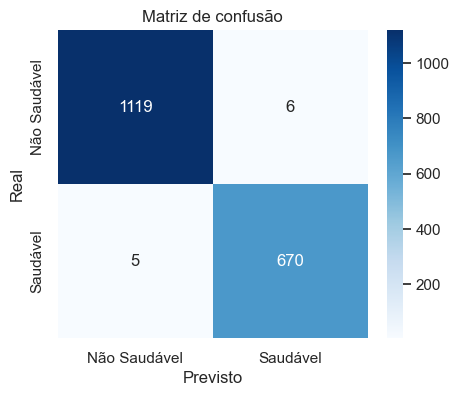


Total de erros: 11 de 1800 amostras (0.6%)

Distribuição dos erros por classe real:
y_true
0    6
1    5


In [58]:
melhor_modelo = mlp
melhor_nome = 'Rede Neural MLP'

# Avaliar o modelo selecionado sobre os dados de teste
if 'melhor_modelo' in globals() and 'X_test_prep_df' in globals() and 'y_test' in globals():
    y_pred = melhor_modelo.predict(X_test_prep_df)
    y_prob = melhor_modelo.predict_proba(X_test_prep_df)[:, 1]

    acuracia = accuracy_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc_roc = roc_auc_score(y_test, y_prob)

    print(f'Melhor modelo: {melhor_nome}')
    print(f'Acurácia: {acuracia:.4f}')
    print(f'Precisão: {precisao:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'AUC-ROC: {auc_roc:.4f}')
    print('\nRelatório de classificação:')
    print(classification_report(y_test, y_pred, target_names=['Não Saudável', 'Saudável']))

    cm = confusion_matrix(y_test, y_pred)
    print('\nMatriz de confusão:')
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Não Saudável', 'Saudável'],
                yticklabels=['Não Saudável', 'Saudável'])
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.title('Matriz de confusão')
    plt.show()

    erros = X_test_prep_df.copy()
    erros['y_true'] = y_test
    erros['y_pred'] = y_pred
    erros['acertou'] = (y_test == y_pred)
    erros = erros[~erros['acertou']]

    print(f'\nTotal de erros: {len(erros)} de {len(X_test_prep_df)} amostras ({len(erros) / len(X_test_prep_df):.1%})')
    print('\nDistribuição dos erros por classe real:')
    print(erros['y_true'].value_counts().to_string())
else:
    print('Variáveis de treino/teste ou modelo não encontradas.')

In [61]:
y_pred_nvb = nb.predict(X_test_prep_df)
y_prob_nvb = nb.predict_proba(X_test_prep_df)[:, 1]

y_pred_mlp = mlp.predict(X_test_prep_df)
y_prob_mlp = mlp.predict_proba(X_test_prep_df)[:, 1]

In [62]:
acc_nvb = accuracy_score(y_test, y_pred_nvb)
prec_nvb = precision_score(y_test, y_pred_nvb, pos_label=1, zero_division=0)
rec_nvb = recall_score(y_test, y_pred_nvb, pos_label=1, zero_division=0)
f1_nvb = f1_score(y_test, y_pred_nvb, pos_label=1, zero_division=0)
auc_nvb = roc_auc_score(y_test, y_prob_nvb)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
rec_mlp = recall_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
f1_mlp = f1_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
auc_mlp = roc_auc_score(y_test, y_prob_mlp)

In [63]:
acc_nvb = accuracy_score(y_test, y_pred_nvb)
prec_nvb = precision_score(y_test, y_pred_nvb, pos_label=1, zero_division=0)
rec_nvb = recall_score(y_test, y_pred_nvb, pos_label=1, zero_division=0)
f1_nvb = f1_score(y_test, y_pred_nvb, pos_label=1, zero_division=0)
auc_nvb = roc_auc_score(y_test, y_prob_nvb)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
rec_mlp = recall_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
f1_mlp = f1_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
auc_mlp = roc_auc_score(y_test, y_prob_mlp)

In [64]:
resultados = pd.DataFrame([
{'Modelo': 'Naive Bayes', 'Acurácia': acc_nvb, 'Precisão': prec_nvb, 'Recall': rec_nvb, 'F1-Score': f1_nvb, 'AUC': auc_nvb},
{'Modelo': 'Rede Neural MLP', 'Acurácia': acc_mlp, 'Precisão': prec_mlp, 'Recall': rec_mlp, 'F1-Score': f1_mlp, 'AUC': auc_mlp}
]).sort_values('F1-Score', ascending=False)

print('\nTabela comparativa (ordenada por F1-Score):')
display(resultados.round(4))


Tabela comparativa (ordenada por F1-Score):


,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC
1,Rede Neural MLP,0.9939,0.9911,0.9926,0.9919,0.9998
0,Naive Bayes,0.8722,0.8326,0.8252,0.8289,0.9433


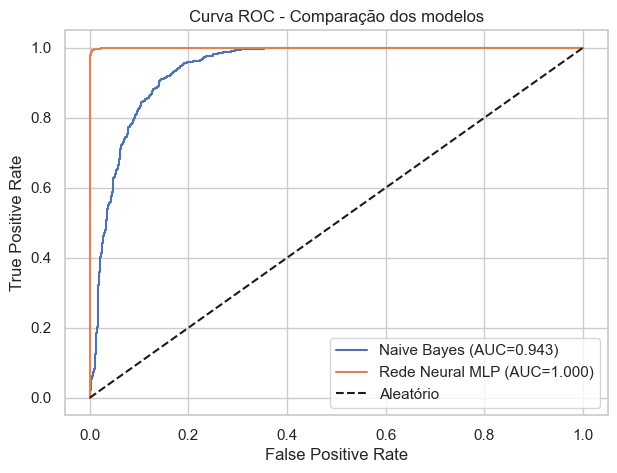

In [67]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
    )


fpr_nvb, tpr_nvb, _ = roc_curve(y_test, y_prob_nvb)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)

plt.figure(figsize=(7, 5))
plt.plot(fpr_nvb, tpr_nvb, label=f'Naive Bayes (AUC={auc_nvb:.3f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'Rede Neural MLP (AUC={auc_mlp:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Comparação dos modelos')
plt.legend()
plt.grid(True)
plt.show()

Os resultados indicam um resultado quase perfeito para a predição de saudavel e não saudavel relacionada a variavel alvo, apesar de saber que o modelo pode ter "aprendido" com os dados para ter um resultado tão satisfátorio, também acredito que a predição que é realizada não parece ser tão dificil para identificar se uma pessoa é saudavel ou não. Avaliando diferença de calorias, peso, idade, genero, atividade fisica e tipo de dieta, acredito que seja possivel identificar se a pessoa leva uma vida saudavel ou não e mesmo se não estiver em sobrepeso ou acima, acredito ser possível dizer que ela não está indo por um caminho bom e que deveria pensar em mudar de hábitos para melhorar sua saude.

O Algoritmo das redes neurais demorou um pouco mais para rodar, porém ele encontrou as melhoras saidas e menor quantidade de erros, portanto, se fosse escolher um modelo, ainda iria utilizar o redes neurais.
